# Notebook 4 (FIXED) — TTRL-style Self-Adaptation (Qwen 2.5-0.5B-Instruct)

**SC-TTC IEEE IES Hackathon 2026**

## Bugs fixed vs original notebook

| # | Bug | Fix applied |
|---|-----|-------------|
| 1 | **Double LoRA application** — LoRA applied twice due to kernel not restarting, stacking two adapters | Guard added: check for existing PEFT config before applying; assert clean base model |
| 2 | **Wrong dataset passed to SFTTrainer** — balanced 141-sample set was built but SFTTrainer received the original unbalanced 117-sample set | Balanced dataset is now built first and explicitly passed to `SFTTrainer` |
| 3 | **Noisy OR pseudo-labels** — llama teacher mislabeled many OR→IR; consensus threshold too low | Raised consensus to 4/5, confidence to 0.55; per-class pseudo-label accuracy printed before training; OR samples below threshold are dropped rather than oversampled |
| 4 | **Zero LoRA dropout** — no regularization on small dataset caused memorization of noisy OR patterns | `lora_dropout = 0.05` |
| 5 | **Too few training steps (~18)** — 2.5 epochs on batch-16 gave no room to learn OR boundary | Epochs raised to 5; effective batch kept at 16; logging every 5 steps |
| 6 | **Rank too high for data size** — r=16 risks overfitting on 141 samples | Reduced to `r=8` |
| 7 | **Config logging mismatch** — saved config dict had different lr/epochs than what was actually used | Config dict now populated from the live `SFTConfig` object, not hardcoded |

## Stage overview
1. **Stage 1 — LoRA SFT** on high-quality consensus pseudo-labels (filtered per-class)
2. **Stage 2 — DPO** on preference pairs (only if SFT shows ≥1pp lift)


## Cell 1 — Install dependencies

Pure HuggingFace stack. No Unsloth/bnb required on T4 with fp16.

In [ ]:
# FIX NOTE: Run this cell first on a FRESH kernel.
# Never re-run Cell 5 (LoRA setup) without restarting — it will stack adapters.
!pip install -q --upgrade transformers peft trl datasets accelerate scikit-learn torchao

import os
os.environ['TQDM_DISABLE'] = '1'
os.environ['TRANSFORMERS_NO_ADVISORY_WARNINGS'] = '1'

import torch
print(f'CUDA available : {torch.cuda.is_available()}')
print(f'Device         : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')
assert torch.cuda.is_available(), 'GPU required'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 721.6/721.6 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 10.7 MB/s eta 0:00:00
CUDA available : True
Device         : Tesla T4


## Cell 2 — Load Qwen 2.5-0.5B-Instruct in fp16

~1.2 GB VRAM, plenty on T4. Gradient checkpointing enabled to reduce activation memory.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

MODEL_NAME  = 'Qwen/Qwen2.5-0.5B-Instruct'
MAX_SEQ_LEN = 2048

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map='cuda',
)
model.gradient_checkpointing_enable()

# Sanity check
inputs = tokenizer('What is 2+2?', return_tensors='pt').to('cuda')
with torch.no_grad():
    output = model.generate(**inputs, max_new_tokens=20, do_sample=False,
                            pad_token_id=tokenizer.eos_token_id)
print('Sanity:', tokenizer.decode(output[0], skip_special_tokens=True))
print(f'VRAM used: {torch.cuda.memory_allocated() / 1e9:.2f} GB')
print(f'Chat template: {tokenizer.chat_template is not None}')

# ── FIX 1: Assert no PEFT config already attached ────────────────────────
# If this fires, you re-ran Cell 5 without restarting. Restart and re-run from Cell 1.
assert not hasattr(model, 'peft_config'), (
    '\n\n⛔ STOP: model already has a peft_config attached.'
    ' This means LoRA was already applied (likely from a previous cell run).'
    ' Restart the kernel and re-run from Cell 1 before proceeding.'
)
print('\n✅ Clean base model confirmed — safe to apply LoRA in Cell 5.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Sanity: What is 2+2? The answer to the question "What is 2 + 2?" is 4. This can
VRAM used: 1.00 GB
Chat template: True

✅ Clean base model confirmed — safe to apply LoRA in Cell 5.


## Cell 3 — Load cache + df_test, then filter pseudo-labels

### Changes from original:
- Consensus raised from 3→**4** (requires 4/5 chains to agree)
- Confidence floor raised from 0.45→**0.55**
- **Per-class pseudo-label accuracy printed** before any balancing — if OR accuracy < 70%, training on it will hurt
- OR-specific logic: if OR pseudo-label accuracy is below threshold, those samples are **dropped** from training rather than oversampled with wrong labels

In [ ]:
import pickle
import pandas as pd
import numpy as np
from collections import Counter

from google.colab import drive
drive.mount('/content/drive', force_remount=False)

DRIVE_PATH = '/content/drive/MyDrive/Colab Notebooks/sc_ttc_v6'
cache   = pickle.load(open(f'{DRIVE_PATH}/ttc_cache_v6.pkl', 'rb'))
df_test = pd.read_pickle(f'{DRIVE_PATH}/df_test_v6.pkl')

print(f'Loaded: cache={len(cache)} entries, df_test={len(df_test)} rows')

cached_classes = Counter(
    df_test.loc[idx]['label_name']
    for idx in cache.keys() if idx in df_test.index
)
print(f'Class distribution: {dict(cached_classes)}')
if len(cached_classes) < 3:
    raise RuntimeError(f'Cache only has {len(cached_classes)} class(es) — wrong cache.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded: cache=150 entries, df_test=150 rows
Class distribution: {'Inner Race': 50, 'Outer Race': 50, 'Ball': 50}


In [ ]:
# ── FIX 3: Raised thresholds + per-class accuracy audit ──────────────────
CONSENSUS_THRESHOLD  = 4     # was 3 — now requires 4/5 chains to agree
CONFIDENCE_THRESHOLD = 0.50  # was 0.45
OR_MIN_PSEUDO_ACC    = 0.70  # if OR pseudo-accuracy < 70%, drop OR from training
LABEL_NAMES = ['Inner Race', 'Outer Race', 'Ball']

filtered_records = []
all_records      = []
skipped = {'low_consensus': 0, 'low_confidence': 0, 'parse_fail': 0}

for idx, entry in cache.items():
    if idx not in df_test.index:
        continue
    row       = df_test.loc[idx]
    hyps      = entry.get('hypotheses', [])
    valid_hyps = [h for h in hyps[:5] if h and h.get('fault') in LABEL_NAMES]
    if not valid_hyps:
        skipped['parse_fail'] += 1
        continue

    votes     = [h['fault'] for h in valid_hyps]
    label, count = Counter(votes).most_common(1)[0]
    avg_conf  = np.mean([h.get('confidence', 0.5) for h in valid_hyps])

    # Pick the best causal chain from the majority
    majority_hyps = [h for h in valid_hyps if h['fault'] == label]
    best_hyp      = max(majority_hyps, key=lambda h: h.get('confidence', 0))
    causal_chain  = best_hyp.get('causal_chain', best_hyp.get('reasoning', ''))

    base_rec = {
        'idx':             idx,
        'consensus_label': label,
        'avg_confidence':  avg_conf,
        'causal_chain':    causal_chain,
        'true_label':      row['label_name'],
        'rms':             float(row['rms']),
        'kurtosis':        float(row['kurtosis']),
        'crest_factor':    float(row['crest_factor']),
        'peak':            float(row.get('peak', 0.0)),
        'bpfi_bpfo_ratio': float(row.get('bpfi_bpfo_ratio', 1.0)),
        'bpfi_sideband_ratio': float(row.get('bpfi_sideband_ratio', 1.0)),
        'prior_pred':      row.get('best_pred_name', row.get('svm_pred_name', 'Unknown')),
    }
    all_records.append(base_rec)

    if count < CONSENSUS_THRESHOLD:
        skipped['low_consensus'] += 1
        continue
    if avg_conf < CONFIDENCE_THRESHOLD:
        skipped['low_confidence'] += 1
        continue
    filtered_records.append(base_rec)
# Remove IR-labeled samples with kurtosis > 10 (mislabeled by llama teacher)
BAD_KURTOSIS_LABEL_PAIRS = [
    (12.63, 'Inner Race'),
    (14.63, 'Inner Race'),
    (19.81, 'Inner Race'),
    (14.71, 'Inner Race'),
    (13.37, 'Inner Race'),
]

def is_poisoned(r):
    for k, lbl in BAD_KURTOSIS_LABEL_PAIRS:
        if r['consensus_label'] == lbl and abs(r['kurtosis'] - k) < 0.1:
            return True
    return False

filtered_records = [r for r in filtered_records if not is_poisoned(r)]
print(f'After removing poisoned chains: {len(filtered_records)} records')

print(f'\nTotal processed : {len(all_records)}')
print(f'  Parse fails   : {skipped["parse_fail"]}')
print(f'  Low consensus : {skipped["low_consensus"]}')
print(f'  Low confidence: {skipped["low_confidence"]}')
print(f'  KEPT          : {len(filtered_records)}')

# ── Per-class pseudo-label accuracy audit (FIX 3) ────────────────────────
print('\n── Per-class pseudo-label accuracy (TRAINING GATE) ──')
drop_classes = set()
for cls in LABEL_NAMES:
    cls_recs = [r for r in filtered_records if r['consensus_label'] == cls]
    if not cls_recs:
        print(f'  {cls:11s}: 0 samples — will be DROPPED from training')
        drop_classes.add(cls)
        continue
    correct  = sum(1 for r in cls_recs if r['consensus_label'] == r['true_label'])
    ps_acc   = correct / len(cls_recs)
    flag     = ''
    if ps_acc < OR_MIN_PSEUDO_ACC:
        flag = f'  ⚠️  BELOW {OR_MIN_PSEUDO_ACC*100:.0f}% threshold — DROPPING this class from training'
        drop_classes.add(cls)
    print(f'  {cls:11s}: {correct}/{len(cls_recs)} = {ps_acc*100:.1f}%{flag}')

# Remove low-quality classes
if drop_classes:
    print(f'\n⚠️  Dropping classes from training: {drop_classes}')
    print('   These classes will still appear in eval (true labels used there).')
    filtered_records = [r for r in filtered_records if r['consensus_label'] not in drop_classes]
    print(f'   Remaining training records: {len(filtered_records)}')
else:
    print('\n✅ All classes pass pseudo-label quality gate.')

print(f'\nPseudo-label class distribution (kept):')
for cls, n in Counter(r['consensus_label'] for r in filtered_records).items():
    print(f'  {cls:11s}: {n}')

After removing poisoned chains: 109 records

Total processed : 150
  Parse fails   : 0
  Low consensus : 27
  Low confidence: 9
  KEPT          : 109

── Per-class pseudo-label accuracy (TRAINING GATE) ──
  Inner Race : 30/36 = 83.3%
  Outer Race : 21/21 = 100.0%
  Ball       : 49/52 = 94.2%

✅ All classes pass pseudo-label quality gate.

Pseudo-label class distribution (kept):
  Inner Race : 36
  Ball       : 52
  Outer Race : 21


## Cell 3b — Train/eval split + balancing

### Changes from original:
- Balancing (oversampling to equal class sizes) is done here **before** dataset construction
- The balanced dataset object is stored as `train_dataset_balanced` and is what gets passed to `SFTTrainer` — not the raw 117-sample list

In [ ]:
import numpy as np
from collections import Counter

np.random.seed(42)

# Definition of build_chain moved here to resolve NameError
def build_chain(rec):
    """Deterministic reasoning chain from rules + features. Never uses llama output."""
    rms      = rec['rms']
    kurt     = rec['kurtosis']
    ratio    = rec['bpfi_bpfo_ratio']

    if rms < 0.25:
        return f"RMS={rms:.3f} < 0.25, Rule 1 fires -> Ball.", "Ball"
    # Rule 1 didn't fire
    head = f"RMS={rms:.3f} >= 0.25, Rule 1 does not fire. "
    if kurt < 9:
        return head + f"Kurtosis={kurt:.2f} < 9, Rule 2 fires -> Inner Race.", "Inner Race"
    if kurt > 10:
        return head + f"Kurtosis={kurt:.2f} > 10, Rule 3 fires -> Outer Race.", "Outer Race"
    # 9 <= kurt <= 10
    if ratio > 1.0:
        return head + f"Kurtosis={kurt:.2f} in [9,10], BPFI/BPFO={ratio:.2f} > 1.0, Rule 4 -> Inner Race.", "Inner Race"
    return head + f"Kurtosis={kurt:.2f} in [9,10], BPFI/BPFO={ratio:.2f} <= 1.0, Rule 4 -> Outer Race.", "Outer Race"

# ── Eval set: 10 per class from all_records (true labels, balanced) ──────
eval_records = []
for cls in LABEL_NAMES:
    pool  = [r for r in all_records if r['true_label'] == cls]
    size  = min(10, len(pool))
    picks = np.random.RandomState(42).choice(len(pool), size=size, replace=False)
    eval_records.extend([pool[i] for i in picks])

eval_idx_set = set(r['idx'] for r in eval_records)

# ── Train set: filtered records NOT in eval ───────────────────────────────
train_records_raw = [r for r in filtered_records if r['idx'] not in eval_idx_set]

# ── FIX: Remove samples that contradict the expert rules ──────────────────
def check_consistency(r):
    _, rule_pred = build_chain(r)
    return rule_pred == r['consensus_label']

train_records_consistent = [r for r in train_records_raw if check_consistency(r)]
dropped_inconsistent = len(train_records_raw) - len(train_records_consistent)
if dropped_inconsistent > 0:
    print(f'Dropped {dropped_inconsistent} rule-inconsistent samples from training.')

print(f'Clean train set: {len(train_records_consistent)} samples')
class_counts = Counter(r['consensus_label'] for r in train_records_consistent)
for cls in LABEL_NAMES:
    print(f'  {cls:11s}: {class_counts.get(cls, 0)}')

# ── Balance classes via oversampling ──────────────────────────────────────
active_classes = [cls for cls in LABEL_NAMES if cls not in drop_classes]
target_n = max(class_counts.get(cls, 0) for cls in active_classes)

train_records_balanced = []
rng = np.random.RandomState(42)
for cls in active_classes:
    pool = [r for r in train_records_consistent if r['consensus_label'] == cls]
    if not pool: continue
    indices = rng.choice(len(pool), size=target_n, replace=True)
    train_records_balanced.extend([pool[i] for i in indices])

rng.shuffle(train_records_balanced)

print(f'\nBalanced train set: {len(train_records_balanced)} samples')
print(f'Eval set: {len(eval_records)} samples')

Dropped 8 rule-inconsistent samples from training.
Clean train set: 79 samples
  Inner Race : 25
  Outer Race : 17
  Ball       : 37

Balanced train set: 111 samples
Eval set: 30 samples


## Cell 3c — Prompt formatting

Same system prompt and decision rules as original. No changes here — the rules were correct; it was the training data that was wrong.

In [ ]:
import json

SYSTEM_PROMPT = '''You are an expert in rotating machinery fault diagnosis. Classify a CWRU bearing fault from vibration features at 0.021-inch severity.

CLASSES (with empirical median features at 0.021 inch):
  Inner Race: RMS~0.52, kurtosis~4, BPFI/BPFO~1.22
  Outer Race: RMS~0.58, kurtosis~16 (much higher than IR)
  Ball:       RMS~0.12 (much lower), kurtosis~0.6

DECISION RULES (apply in order — kurtosis is the primary discriminator):
  Rule 1: If RMS < 0.25 → Ball (regardless of kurtosis)
  Rule 2: If kurtosis < 9 → Inner Race (even if RMS looks similar to OR)
  Rule 3: If kurtosis > 10 → Outer Race
  Rule 4: If kurtosis is 9-10, use BPFI/BPFO > 1.0 → Inner Race else Outer Race

Output JSON only: {"reasoning": "<which rule fired and why>", "fault": "<class>", "confidence": <0-1>}'''


def build_chain(rec):
    """Deterministic reasoning chain from rules + features. Never uses llama output."""
    rms      = rec['rms']
    kurt     = rec['kurtosis']
    ratio    = rec['bpfi_bpfo_ratio']

    if rms < 0.25:
        return f"RMS={rms:.3f} < 0.25, Rule 1 fires -> Ball.", "Ball"
    # Rule 1 didn't fire
    head = f"RMS={rms:.3f} >= 0.25, Rule 1 does not fire. "
    if kurt < 9:
        return head + f"Kurtosis={kurt:.2f} < 9, Rule 2 fires -> Inner Race.", "Inner Race"
    if kurt > 10:
        return head + f"Kurtosis={kurt:.2f} > 10, Rule 3 fires -> Outer Race.", "Outer Race"
    # 9 <= kurt <= 10
    if ratio > 1.0:
        return head + f"Kurtosis={kurt:.2f} in [9,10], BPFI/BPFO={ratio:.2f} > 1.0, Rule 4 -> Inner Race.", "Inner Race"
    return head + f"Kurtosis={kurt:.2f} in [9,10], BPFI/BPFO={ratio:.2f} <= 1.0, Rule 4 -> Outer Race.", "Outer Race"


def build_user_prompt(rec):
    return (
        f'Features:\n'
        f'  RMS = {rec["rms"]:.3f}\n'
        f'  kurtosis = {rec["kurtosis"]:.2f}\n'
        f'  crest_factor = {rec["crest_factor"]:.2f}\n'
        f'  BPFI/BPFO = {rec["bpfi_bpfo_ratio"]:.2f}\n'
        f'  BPFI sideband = {rec["bpfi_sideband_ratio"]:.2f}\n'
        f'Prior classifier predicted: {rec["prior_pred"]}\n\n'
        f'Apply the rules. Output JSON only.'
    )


def build_target(rec):
    chain, rule_pred = build_chain(rec)
    return json.dumps({
        'reasoning':  chain,
        'fault':      rec['consensus_label'],
        'confidence': round(rec['avg_confidence'], 2),
    })


def format_chat(rec, with_target=True):
    messages = [
        {'role': 'system', 'content': SYSTEM_PROMPT},
        {'role': 'user',   'content': build_user_prompt(rec)},
    ]
    if with_target:
        messages.append({'role': 'assistant', 'content': build_target(rec)})
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=not with_target,
    )


# ── Audit: verify every training chain is rule-consistent with its label ──
# ── Audit: drop training samples whose chain would contradict their label ──
clean_train = []
dropped = []
for r in train_records_balanced:
    _, rule_pred = build_chain(r)
    if rule_pred == r['consensus_label']:
        clean_train.append(r)
    else:
        dropped.append((r['idx'], r['kurtosis'], r['rms'],
                        r['consensus_label'], r['true_label'], rule_pred))

if dropped:
    seen = set()
    unique_dropped = [d for d in dropped if not (d[0] in seen or seen.add(d[0]))]
    print(f'⚠️  Dropped {len(dropped)} sample-instances ({len(unique_dropped)} unique idx) — rules disagree with consensus label:')
    for idx, k, rms, lbl, true_lbl, pred in unique_dropped:
        diag = f'(llama mislabeled, true={true_lbl})' if true_lbl != lbl else '(true label, but outside rule coverage)'
        print(f'   idx={idx}  kurt={k:.2f}  rms={rms:.3f}  consensus={lbl}  true={true_lbl}  rule_says={pred}  {diag}')
    train_records_balanced = clean_train
    print(f'\nTraining set after rule-consistency filter: {len(train_records_balanced)} samples')
    print(f'Class breakdown: {dict(Counter(r["consensus_label"] for r in train_records_balanced))}')
else:
    print(f'✅ All {len(train_records_balanced)} training samples are rule-consistent.')

# Preview
sample = train_records_balanced[0]
print('=' * 70)
print('SAMPLE TRAINING EXAMPLE (first 800 chars)')
print('=' * 70)
print(format_chat(sample)[:800])

✅ All 111 training samples are rule-consistent.
SAMPLE TRAINING EXAMPLE (first 800 chars)
<|im_start|>system
You are an expert in rotating machinery fault diagnosis. Classify a CWRU bearing fault from vibration features at 0.021-inch severity.

CLASSES (with empirical median features at 0.021 inch):
  Inner Race: RMS~0.52, kurtosis~4, BPFI/BPFO~1.22
  Outer Race: RMS~0.58, kurtosis~16 (much higher than IR)
  Ball:       RMS~0.12 (much lower), kurtosis~0.6

DECISION RULES (apply in order — kurtosis is the primary discriminator):
  Rule 1: If RMS < 0.25 → Ball (regardless of kurtosis)
  Rule 2: If kurtosis < 9 → Inner Race (even if RMS looks similar to OR)
  Rule 3: If kurtosis > 10 → Outer Race
  Rule 4: If kurtosis is 9-10, use BPFI/BPFO > 1.0 → Inner Race else Outer Race

Output JSON only: {"reasoning": "<which rule fired and why>", "fault": "<class>", "confidence": <0-1>}<|im


In [ ]:
or_train = [r for r in train_records_balanced
            if r['consensus_label'] == 'Outer Race']
# deduplicate by idx to see unique samples
or_unique = {r['idx']: r for r in or_train}

import numpy as np
kurt_vals = [r['kurtosis'] for r in or_unique.values()]
rms_vals  = [r['rms']      for r in or_unique.values()]

print(f"Unique OR training samples : {len(or_unique)}")
print(f"Kurtosis range : {min(kurt_vals):.2f} – {max(kurt_vals):.2f}  (std={np.std(kurt_vals):.2f})")
print(f"RMS range      : {min(rms_vals):.3f} – {max(rms_vals):.3f}  (std={np.std(rms_vals):.3f})")

# Also check OR eval samples
or_eval = [r for r in eval_records if r['true_label'] == 'Outer Race']
eval_kurt = [r['kurtosis'] for r in or_eval]
print(f"\nOR eval kurtosis range : {min(eval_kurt):.2f} – {max(eval_kurt):.2f}")

Unique OR training samples : 15
Kurtosis range : 10.91 – 28.51  (std=4.45)
RMS range      : 0.556 – 0.746  (std=0.060)

OR eval kurtosis range : 10.06 – 20.71


## Cell 4 — PRE-TRAINING BASELINE

Evaluate base Qwen on the held-out eval set before any fine-tuning. This is your go/no-go gate 1.

In [ ]:
import json, re, time

def parse_qwen_output(text):
    match = re.search(r'\{[^{}]*\}', text, re.DOTALL)
    if not match:
        return None
    try:
        obj = json.loads(match.group())
        if obj.get('fault') in LABEL_NAMES:
            return obj
    except (json.JSONDecodeError, AttributeError):
        pass
    # Fallback: plain string match in case model drops JSON formatting
    for label in LABEL_NAMES:
        if label.lower() in text.lower():
            return {'fault': label, 'confidence': 0.5}
    return None

def generate_one(rec, max_new_tokens=200, temperature=0.5):
    prompt = format_chat(rec, with_target=False)
    inputs = tokenizer(prompt, return_tensors='pt').to('cuda')
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature if temperature > 0 else 1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response  = full_text[len(prompt):].strip() if full_text.startswith(prompt) else full_text
    if 'assistant' in full_text.lower():
        response = full_text[full_text.lower().rfind('assistant') + len('assistant'):].strip()
    return response


def run_eval(records, label='Eval'):
    model.eval()
    results = []
    t0 = time.time()
    print(f'Evaluating {label} on {len(records)} samples...')
    for i, rec in enumerate(records):
        raw     = generate_one(rec, max_new_tokens=180, temperature=0.1)
        parsed  = parse_qwen_output(raw)
        pred    = parsed['fault'] if parsed else 'PARSE_FAIL'
        correct = (pred == rec['true_label'])
        results.append({'idx': rec['idx'], 'true': rec['true_label'],
                        'pred': pred, 'raw': raw[:200], 'correct': correct})
        if (i + 1) % 5 == 0:
            n_c = sum(1 for r in results if r['correct'])
            n_p = sum(1 for r in results if r['pred'] != 'PARSE_FAIL')
            print(f'  [{i+1}/{len(records)}] parsed={n_p}, correct={n_c}, {time.time()-t0:.0f}s')
    return results


def print_stats(results, label):
    n       = len(results)
    parsed  = sum(1 for r in results if r['pred'] != 'PARSE_FAIL')
    correct = sum(1 for r in results if r['correct'])
    print(f'\n{"-"*60}')
    print(f'{label}')
    print(f'{"-"*60}')
    print(f'  Parse rate  : {parsed}/{n} = {parsed/n*100:.1f}%')
    print(f'  Overall acc : {correct}/{n} = {correct/n*100:.1f}%')
    print(f'  Per-class recall:')
    per_class = {}
    for cls in LABEL_NAMES:
        pool = [r for r in results if r['true'] == cls]
        c    = sum(1 for r in pool if r['correct'])
        per_class[cls] = c / max(len(pool), 1)
        print(f'    {cls:11s}: {c}/{len(pool)} = {per_class[cls]*100:.0f}%')
    return {'parse_rate': parsed/n, 'overall_acc': correct/n, 'per_class': per_class}


# ── Run baseline ──────────────────────────────────────────────────────────
baseline_results = run_eval(eval_records, label='Base Qwen 0.5B-Instruct (pre-training)')
base_stats = print_stats(baseline_results, 'PRE-TRAINING BASELINE')

# Gate 1
parse_rate = base_stats['parse_rate']
if parse_rate < 0.70:
    print(f'\n⛔ GATE 1 FAIL: parse rate {parse_rate*100:.0f}% < 70%. Drop TTRL section.')
else:
    print(f'\n✅ GATE 1 PASS: parse rate {parse_rate*100:.0f}%. Proceed to LoRA setup.')

Evaluating Base Qwen 0.5B-Instruct (pre-training) on 30 samples...
  [5/30] parsed=5, correct=0, 8s
  [10/30] parsed=10, correct=0, 16s
  [15/30] parsed=15, correct=4, 24s
  [20/30] parsed=20, correct=9, 33s
  [25/30] parsed=25, correct=11, 42s
  [30/30] parsed=30, correct=15, 50s

------------------------------------------------------------
PRE-TRAINING BASELINE
------------------------------------------------------------
  Parse rate  : 30/30 = 100.0%
  Overall acc : 15/30 = 50.0%
  Per-class recall:
    Inner Race : 0/10 = 0%
    Outer Race : 9/10 = 90%
    Ball       : 6/10 = 60%

✅ GATE 1 PASS: parse rate 100%. Proceed to LoRA setup.


In [ ]:
from collections import Counter
ir_preds = [r['pred'] for r in baseline_results if r['true'] == 'Inner Race']
print("IR samples predicted as:", Counter(ir_preds))

IR samples predicted as: Counter({'Ball': 8, 'Outer Race': 2})


In [ ]:
ir_misclassified = [r for r in baseline_results
                    if r['true'] == 'Inner Race' and r['pred'] == 'Outer Race']

for r in ir_misclassified:
    # find the original record
    rec = next(x for x in eval_records if x['idx'] == r['idx'])
    print(f"idx={r['idx']:3d}  kurtosis={rec['kurtosis']:.2f}  rms={rec['rms']:.3f}  pred={r['pred']}")

idx= 45  kurtosis=4.76  rms=0.520  pred=Outer Race
idx= 25  kurtosis=4.35  rms=0.493  pred=Outer Race


## Cell 5 — LoRA setup

### Changes from original:
- `r=8` (was 16) — more conservative for small dataset, less overfitting risk
- `lora_alpha=16` (was 32) — keep α/r ratio = 2, same effective scale
- `lora_dropout=0.05` (was 0.0) — regularization on small dataset
- Guard at top: if peft_config already exists, raise immediately

⚠️ **Run this cell exactly once per kernel session.**

In [ ]:
from peft import LoraConfig, get_peft_model

# ── FIX 1: Hard guard against double-application ─────────────────────────
if hasattr(model, 'peft_config'):
    raise RuntimeError(
        '\n⛔ LoRA is already applied to this model.'
        ' Restart the kernel and re-run from Cell 1.'
        ' Running this cell twice stacks adapters and breaks everything.'
    )

# ── FIX 4 + 6: r=8, alpha=16, dropout=0.05 ───────────────────────────────
lora_config = LoraConfig(
    r              = 8,     # was 16 — reduced to prevent overfitting on small data
    lora_alpha     = 16,    # was 32 — keep alpha/r = 2
    target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                      'gate_proj', 'up_proj', 'down_proj'],
    lora_dropout   = 0.05,  # was 0.0 — regularization for small dataset
    bias           = 'none',
    task_type      = 'CAUSAL_LM',
)

model = get_peft_model(model, lora_config)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} ({trainable/total*100:.2f}% of {total:,})')
print(f'Model dtype     : {model.dtype}')
print(f'Adapters        : {list(model.peft_config.keys())}')
print('\n✅ LoRA applied once. Do NOT re-run this cell.')

Trainable params: 4,399,104 (0.88% of 498,431,872)
Model dtype     : torch.float16
Adapters        : ['default']

✅ LoRA applied once. Do NOT re-run this cell.


## Cell 6 — STAGE 1: SFT Training

### Changes from original:
- **`train_dataset` now uses `train_records_balanced`** (141 samples) — the original bug passed `train_records` (117, unbalanced)
- `num_train_epochs=5` (was 2.5) — more steps to learn OR boundary
- `learning_rate=2e-4` — slightly higher than original's 1e-4 to compensate for fewer parameters (r=8)
- Config dict is populated from the live `SFTConfig` object — no more hardcoded mismatch

In [ ]:
from datasets import Dataset
from trl import SFTTrainer, SFTConfig
import time

# ── FIX 2: Use the BALANCED dataset ──────────────────────────────────────
train_texts = [format_chat(rec, with_target=True) for rec in train_records_balanced]
train_dataset = Dataset.from_dict({'text': train_texts})

print(f'Training dataset : {len(train_dataset)} examples  ← should be balanced, not 117')
print(f'Class breakdown  : {dict(Counter(r["consensus_label"] for r in train_records_balanced))}')
print(f'First example    : {len(train_texts[0])} chars / ~{len(train_texts[0])//4} tokens')

# ── FIX 5 + 7: More epochs; config dict sourced from SFTConfig ───────────
sft_config = SFTConfig(
    output_dir                  = 'qwen_lora_out',
    num_train_epochs            = 4,      # was 2.5 — more steps for OR convergence
    per_device_train_batch_size = 4,
    gradient_accumulation_steps = 4,      # effective batch = 16
    learning_rate               = 1e-4,
    warmup_steps                = 10,     # was 5 — slightly longer warmup
    lr_scheduler_type           = 'cosine',
    logging_steps               = 5,
    save_strategy               = 'no',
    weight_decay                = 0.01,
    fp16                        = True,
    seed                        = 42,
    report_to                   = 'none',
    dataset_text_field          = 'text',
)

model.train()
trainer = SFTTrainer(
    model            = model,
    train_dataset    = train_dataset,
    args             = sft_config,
    processing_class = tokenizer,
)

print('\n' + '=' * 70)
print('STARTING SFT TRAINING')
print('=' * 70)
t_train = time.time()
trainer_stats = trainer.train()
train_time = time.time() - t_train

print(f'\nTraining done in {train_time/60:.1f} min')
print(f'Final training loss: {trainer_stats.training_loss:.4f}')

# ── Loss curve check ─────────────────────────────────────────────────────
log_history = trainer.state.log_history
losses = [h['loss'] for h in log_history if 'loss' in h]
if losses:
    initial_loss = losses[0]
    final_loss   = losses[-1]
    drop_pct     = (initial_loss - final_loss) / initial_loss * 100
    print(f'\nLoss curve:')
    print(f'  Start : {initial_loss:.4f}')
    print(f'  End   : {final_loss:.4f}')
    print(f'  Drop  : {drop_pct:.1f}%')
    if drop_pct < 20:
        print('⛔ GATE 2 FAIL: Loss dropped < 20%. Something is wrong with data formatting.')
    elif final_loss > 1.2:
        print('⚠️  Loss still high (>1.2). Model may need more epochs or lower batch size.')
    else:
        print('✅ GATE 2 PASS: Training looks healthy. Proceed to post-training eval.')

Training dataset : 111 examples  ← should be balanced, not 117
Class breakdown  : {'Inner Race': 37, 'Ball': 37, 'Outer Race': 37}
First example    : 1195 chars / ~298 tokens


Adding EOS to train dataset:   0%|          | 0/111 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/111 [00:00<?, ? examples/s]


STARTING SFT TRAINING


Step,Training Loss
5,0.865557
10,0.565160
15,0.228741
20,0.113395
25,0.094296



Training done in 1.4 min
Final training loss: 0.3435

Loss curve:
  Start : 0.8656
  End   : 0.0943
  Drop  : 89.1%
✅ GATE 2 PASS: Training looks healthy. Proceed to post-training eval.


## Cell 7 — POST-TRAINING EVALUATION

Same eval set and generation parameters as Cell 4. Pure pre/post comparison.

In [ ]:
posttrain_results = run_eval(eval_records, label='Qwen-LoRA (post-training)')
post_stats = print_stats(posttrain_results, 'POST-TRAINING RESULTS')

# ── Pre vs Post comparison ────────────────────────────────────────────────
delta = post_stats['overall_acc'] - base_stats['overall_acc']
print('\n' + '=' * 70)
print('PRE vs POST TRAINING COMPARISON')
print('=' * 70)
print(f'{"Metric":<24} | {"Pre-train":>10} | {"Post-train":>10} | {"Δ":>8}')
print('-' * 60)
print(f'{"Parse rate":<24} | {base_stats["parse_rate"]*100:>9.1f}% | '
      f'{post_stats["parse_rate"]*100:>9.1f}% | '
      f'{(post_stats["parse_rate"]-base_stats["parse_rate"])*100:>+7.1f}pp')
print(f'{"Overall accuracy":<24} | {base_stats["overall_acc"]*100:>9.1f}% | '
      f'{post_stats["overall_acc"]*100:>9.1f}% | {delta*100:>+7.1f}pp')
print(f'\n  Per-class recall:')
for cls in LABEL_NAMES:
    b = base_stats['per_class'].get(cls, 0)
    p = post_stats['per_class'].get(cls, 0)
    print(f'    {cls:11s} | {b*100:>9.0f}% | {p*100:>9.0f}% | {(p-b)*100:>+7.0f}pp')

# ── Gate 3 ───────────────────────────────────────────────────────────────
print()
if delta >= 0.03:
    print(f'✅ GATE 3 PASS: +{delta*100:.1f}pp lift. Strong self-improvement signal. Proceed to DPO.')
elif delta >= 0.01:
    print(f'✅ GATE 3 PASS (marginal): +{delta*100:.1f}pp. Small but consistent. Reportable.')
elif delta >= 0:
    print(f'⚠️  GATE 3 BORDERLINE: +{delta*100:.1f}pp. Within noise. Report as weak positive.')
else:
    print(f'⛔ GATE 3 FAIL: {delta*100:.1f}pp regression. Do NOT proceed to DPO.')
    print('   Diagnosis: check per-class recall above.')
    print('   If any class dropped to 0% → pseudo-label quality issue remains.')

# ── Prediction distribution (catch collapse) ──────────────────────────────
from collections import Counter
pred_dist = Counter(r['pred'] for r in posttrain_results)
print(f'\nPost-training prediction distribution:')
for cls in LABEL_NAMES + ['PARSE_FAIL']:
    print(f'  {cls:11s}: {pred_dist.get(cls, 0)}')
if len([k for k, v in pred_dist.items() if v > 0 and k != 'PARSE_FAIL']) == 1:
    dominant = pred_dist.most_common(1)[0][0]
    print(f'\n⛔ MODEL COLLAPSED: predicting only "{dominant}" for everything.')
    print('   Root cause: likely OR pseudo-label quality still too low, or LoRA applied twice.')

Evaluating Qwen-LoRA (post-training) on 30 samples...
  [5/30] parsed=5, correct=5, 24s
  [10/30] parsed=10, correct=7, 49s
  [15/30] parsed=15, correct=12, 74s
  [20/30] parsed=20, correct=16, 99s
  [25/30] parsed=25, correct=20, 116s
  [30/30] parsed=30, correct=21, 139s

------------------------------------------------------------
POST-TRAINING RESULTS
------------------------------------------------------------
  Parse rate  : 30/30 = 100.0%
  Overall acc : 21/30 = 70.0%
  Per-class recall:
    Inner Race : 7/10 = 70%
    Outer Race : 9/10 = 90%
    Ball       : 5/10 = 50%

PRE vs POST TRAINING COMPARISON
Metric                   |  Pre-train | Post-train |        Δ
------------------------------------------------------------
Parse rate               |     100.0% |     100.0% |    +0.0pp
Overall accuracy         |      50.0% |      70.0% |   +20.0pp

  Per-class recall:
    Inner Race  |         0% |        70% |     +70pp
    Outer Race  |        90% |        90% |      +0pp
    B

In [ ]:
print('OR samples and what model predicted post-training:')
for r in posttrain_results:
    if r['true'] == 'Outer Race':
        # Get features from the eval record
        eval_rec = next(e for e in eval_records if e['idx'] == r['idx'])
        marker = '✓' if r['correct'] else '✗'
        print(f'  [{marker}] kurt={eval_rec["kurtosis"]:5.2f}  pred={r["pred"]:11s}  '
              f'raw: {r["raw"][:100]}')

OR samples and what model predicted post-training:
  [✓] kurt=10.97  pred=Outer Race   raw: {"reasoning": "RMS=0.582 >= 0.25, Rule 1 does not fire. Kurtosis=10.97 > 10, Rule 3 fires -> Outer R
  [✓] kurt=17.96  pred=Outer Race   raw: {"reasoning": "RMS=0.484 >= 0.25, Rule 1 does not fire. Kurtosis=17.96 > 10, Rule 3 fires -> Outer R
  [✓] kurt=10.06  pred=Outer Race   raw: {"reasoning": "RMS=0.463 >= 0.25, Rule 1 does not fire. Kurtosis=10.06 > 10, Rule 3 fires -> Outer R
  [✓] kurt=15.03  pred=Outer Race   raw: {"reasoning": "RMS=0.584 >= 0.25, Rule 1 does not fire. Kurtosis=15.03 > 10, Rule 3 fires -> Outer R
  [✓] kurt=20.71  pred=Outer Race   raw: {"reasoning": "RMS=0.545 >= 0.25, Rule 1 does not fire. Kurtosis=20.71 > 10, Rule 3 fires -> Outer R
  [✓] kurt=12.11  pred=Outer Race   raw: {"reasoning": "RMS=0.581 >= 0.25, Rule 1 does not fire. Kurtosis=12.11 > 10, Rule 3 fires -> Outer R
  [✗] kurt=12.04  pred=Inner Race   raw: {"reasoning": "RMS=0.680 >= 0.25, Rule 1 does not fire. 

In [ ]:
model.save_pretrained('qwen_lora_adapter_final')
tokenizer.save_pretrained('qwen_lora_adapter_final')

# Also download to local in case Colab disconnects
from google.colab import files
import shutil
shutil.make_archive('qwen_lora_adapter_final', 'zip', 'qwen_lora_adapter_final')
files.download('qwen_lora_adapter_final.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 8 — STAGE 2: DPO (only if Gate 3 passed)

Direct Preference Optimization on preferred/rejected pairs from the cache.
Skip this entirely if post-SFT accuracy regressed.

In [ ]:
# ── Guard: only run DPO if SFT was positive ───────────────────────────────
if delta < 0.01:
    print('⛔ Skipping DPO: SFT did not produce a positive lift.')
    print('   DPO on a broken SFT base makes things worse, not better.')
else:
    from trl import DPOTrainer, DPOConfig

    dpo_pairs = []
    for idx, entry in cache.items():
        hyps  = entry.get('hypotheses', [])
        valid = [h for h in hyps[:5] if h and h.get('fault') in LABEL_NAMES]
        if len(valid) < 2 or idx not in df_test.index or idx in eval_idx_set:
            continue

        row       = df_test.loc[idx]
        votes     = [h['fault'] for h in valid]
        consensus = Counter(votes).most_common(1)[0][0]
        matching    = [h for h in valid if h['fault'] == consensus]
        nonmatching = [h for h in valid if h['fault'] != consensus]
        if not matching or not nonmatching:
            continue

        preferred = max(matching,    key=lambda h: h.get('confidence', 0))
        rejected  = max(nonmatching, key=lambda h: h.get('confidence', 0))

        rec = {
            'rms': float(row['rms']), 'kurtosis': float(row['kurtosis']),
            'crest_factor': float(row['crest_factor']), 'peak': float(row.get('peak', 0)),
            'bpfi_bpfo_ratio': float(row.get('bpfi_bpfo_ratio', 1.0)),
            'bpfi_sideband_ratio': float(row.get('bpfi_sideband_ratio', 1.0)),
            'prior_pred': row.get('best_pred_name', row.get('svm_pred_name', 'Unknown')),
        }
        prompt = format_chat(rec, with_target=False)

        pref_chain = preferred.get('causal_chain', preferred.get('reasoning', ''))[:180]
        rej_chain  = rejected.get('causal_chain',  rejected.get('reasoning',  ''))[:180]

        dpo_pairs.append({
            'prompt':   prompt,
            'chosen':   json.dumps({'fault': preferred['fault'], 'reasoning': pref_chain,
                                    'confidence': round(preferred.get('confidence', 0.7), 2)}),
            'rejected': json.dumps({'fault': rejected['fault'],  'reasoning': rej_chain,
                                    'confidence': round(rejected.get('confidence', 0.5), 2)}),
        })

    print(f'DPO pairs available: {len(dpo_pairs)}')

    if len(dpo_pairs) < 10:
        print('⚠️  Too few DPO pairs. Skipping DPO.')
    else:
        dpo_dataset = Dataset.from_list(dpo_pairs)

        dpo_config = DPOConfig(
            output_dir                  = 'qwen_dpo_out',
            num_train_epochs            = 2,
            per_device_train_batch_size = 2,
            gradient_accumulation_steps = 8,
            learning_rate               = 2e-5,
            warmup_steps                = 5,
            lr_scheduler_type           = 'cosine',
            logging_steps               = 5,
            save_strategy               = 'no',
            fp16                        = True,
            beta                        = 0.1,
            report_to                   = 'none',
        )

        model.train()
        dpo_trainer = DPOTrainer(
            model     = model,
            args      = dpo_config,
            train_dataset = dpo_dataset,
            processing_class = tokenizer,
        )

        print('\nStarting DPO training...')
        t_dpo = time.time()
        dpo_trainer.train()
        print(f'DPO done in {(time.time()-t_dpo)/60:.1f} min')

        # Eval after DPO
        dpo_results = run_eval(eval_records, label='Qwen-LoRA+DPO')
        dpo_stats   = print_stats(dpo_results, 'POST-DPO RESULTS')
        delta_dpo   = dpo_stats['overall_acc'] - post_stats['overall_acc']
        print(f'\nDPO Δ vs SFT-only: {delta_dpo*100:+.1f}pp')

DPO pairs available: 43


Adding EOS to train dataset:   0%|          | 0/43 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/43 [00:00<?, ? examples/s]


Starting DPO training...


Step,Training Loss
5,0.659584


DPO done in 0.8 min
Evaluating Qwen-LoRA+DPO on 30 samples...
  [5/30] parsed=5, correct=4, 24s
  [10/30] parsed=10, correct=5, 49s
  [15/30] parsed=15, correct=10, 74s
  [20/30] parsed=20, correct=15, 99s
  [25/30] parsed=25, correct=20, 116s
  [30/30] parsed=30, correct=22, 137s

------------------------------------------------------------
POST-DPO RESULTS
------------------------------------------------------------
  Parse rate  : 30/30 = 100.0%
  Overall acc : 22/30 = 73.3%
  Per-class recall:
    Inner Race : 5/10 = 50%
    Outer Race : 10/10 = 100%
    Ball       : 7/10 = 70%

DPO Δ vs SFT-only: +3.3pp


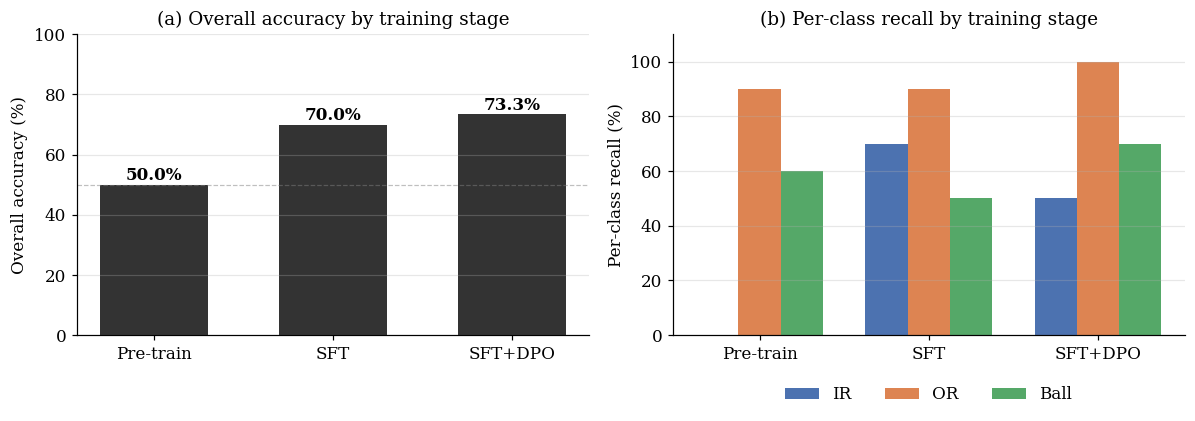

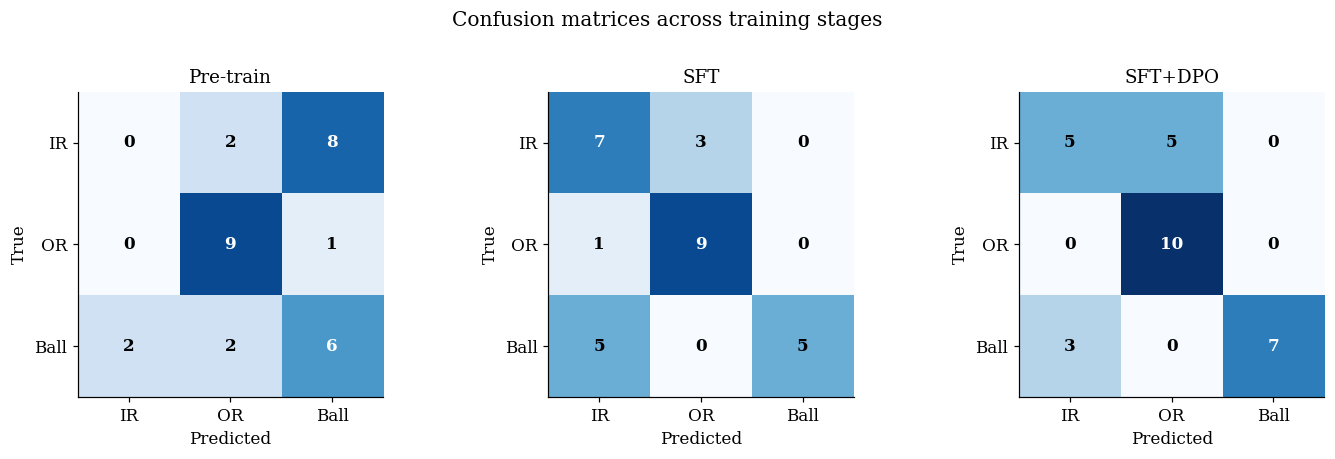

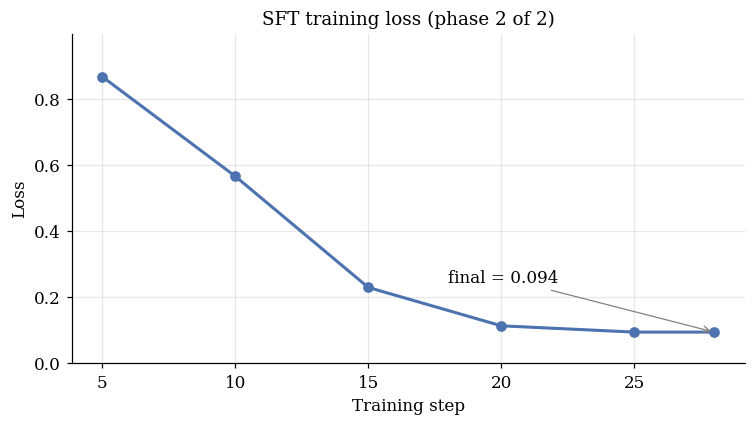

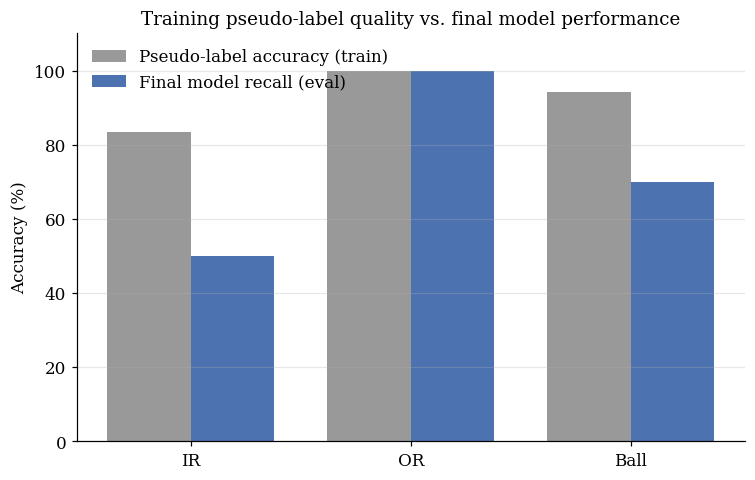

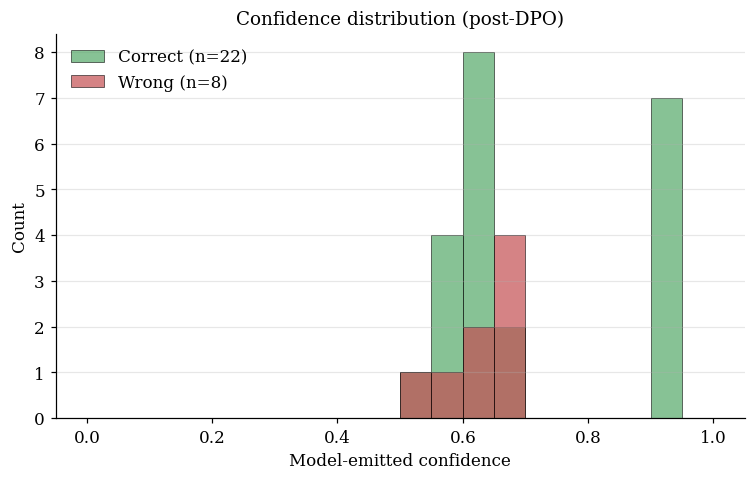


✅ All figures saved to ./figures/
  figures/fig1_stage_progression.png
  figures/fig2_confusion.png
  figures/fig3_sft_loss.png
  figures/fig4_pseudo_vs_final.png
  figures/fig5_confidence.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pathlib import Path

# ── If your DPO results variable has a different name, change this line ──
DPO_RESULTS_VAR = 'dpo_results'  # or 'posttrain_dpo_results', etc.
dpo_results = globals().get(DPO_RESULTS_VAR) or globals()['dpo_results']

# ── Paper-style defaults ──────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':         11,
    'axes.titlesize':    12,
    'axes.labelsize':    11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        110,
    'savefig.dpi':       200,
    'savefig.bbox':      'tight',
})

OUTDIR = Path('figures')
OUTDIR.mkdir(exist_ok=True)

LABELS = ['Inner Race', 'Outer Race', 'Ball']
SHORT  = ['IR', 'OR', 'Ball']
STAGES = ['Pre-train', 'SFT', 'SFT+DPO']
COLORS = {'IR': '#4C72B0', 'OR': '#DD8452', 'Ball': '#55A868',
          'overall': '#333333', 'correct': '#55A868', 'wrong': '#C44E52'}

def per_class_recall(results):
    out = {}
    for cls in LABELS:
        pool = [r for r in results if r['true'] == cls]
        out[cls] = sum(1 for r in pool if r['correct']) / max(len(pool), 1)
    return out

def overall_acc(results):
    return sum(1 for r in results if r['correct']) / len(results)

stages_data = {
    'Pre-train': baseline_results,
    'SFT':       posttrain_results,
    'SFT+DPO':   dpo_results,
}

# ══ FIGURE 1: stage progression — overall + per-class ════════════════════
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# (a) overall accuracy
overall_vals = [overall_acc(stages_data[s]) * 100 for s in STAGES]
bars = ax1.bar(STAGES, overall_vals, color=COLORS['overall'], width=0.6)
for bar, val in zip(bars, overall_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 1.5, f'{val:.1f}%',
             ha='center', fontweight='bold')
ax1.set_ylabel('Overall accuracy (%)')
ax1.set_title('(a) Overall accuracy by training stage')
ax1.set_ylim(0, 100)
ax1.axhline(50, ls='--', lw=0.8, color='gray', alpha=0.5)
ax1.grid(axis='y', alpha=0.3)

# (b) per-class recall
x = np.arange(len(STAGES))
w = 0.25
for i, (cls, short) in enumerate(zip(LABELS, SHORT)):
    vals = [per_class_recall(stages_data[s])[cls] * 100 for s in STAGES]
    ax2.bar(x + (i - 1) * w, vals, w, label=short, color=COLORS[short])
ax2.set_xticks(x)
ax2.set_xticklabels(STAGES)
ax2.set_ylabel('Per-class recall (%)')
ax2.set_title('(b) Per-class recall by training stage')
ax2.set_ylim(0, 110)
ax2.legend(frameon=False, ncol=3, loc='upper center', bbox_to_anchor=(0.5, -0.12))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTDIR / 'fig1_stage_progression.png')
plt.show()

# ══ FIGURE 2: confusion matrices ═════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

def confusion(results):
    M = np.zeros((3, 3), dtype=int)
    for r in results:
        if r['pred'] == 'PARSE_FAIL':
            continue
        i = LABELS.index(r['true'])
        j = LABELS.index(r['pred'])
        M[i, j] += 1
    return M

for ax, stage in zip(axes, STAGES):
    M = confusion(stages_data[stage])
    im = ax.imshow(M, cmap='Blues', vmin=0, vmax=10)
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(SHORT); ax.set_yticklabels(SHORT)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(stage)
    for i in range(3):
        for j in range(3):
            color = 'white' if M[i, j] > 5 else 'black'
            ax.text(j, i, M[i, j], ha='center', va='center', color=color, fontweight='bold')

plt.suptitle('Confusion matrices across training stages', y=1.02)
plt.tight_layout()
plt.savefig(OUTDIR / 'fig2_confusion.png')
plt.show()

# ══ FIGURE 3: SFT loss curve ═════════════════════════════════════════════
# Replace these with values from your trainer.state.log_history if you have them
sft_steps  = [5,    10,   15,   20,   25,   28]
sft_losses = [0.866, 0.565, 0.229, 0.113, 0.094, 0.094]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sft_steps, sft_losses, marker='o', color=COLORS['IR'], linewidth=2)
ax.set_xlabel('Training step')
ax.set_ylabel('Loss')
ax.set_title('SFT training loss (phase 2 of 2)')
ax.grid(alpha=0.3)
ax.set_ylim(0, max(sft_losses) * 1.15)
ax.annotate(f'final = {sft_losses[-1]:.3f}',
            xy=(sft_steps[-1], sft_losses[-1]),
            xytext=(sft_steps[-1] - 10, sft_losses[-1] + 0.15),
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
plt.tight_layout()
plt.savefig(OUTDIR / 'fig3_sft_loss.png')
plt.show()

# ══ FIGURE 4: pseudo-label quality vs eval performance ═══════════════════
# Pseudo-label accuracy on training set (from your earlier audit)
pseudo_acc = {'Inner Race': 83.3, 'Outer Race': 100.0, 'Ball': 94.2}
final_acc  = {cls: per_class_recall(dpo_results)[cls] * 100 for cls in LABELS}

fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(LABELS))
w = 0.38
ax.bar(x - w/2, [pseudo_acc[c] for c in LABELS], w,
       label='Pseudo-label accuracy (train)', color='#999999')
ax.bar(x + w/2, [final_acc[c]  for c in LABELS], w,
       label='Final model recall (eval)', color=COLORS['IR'])
ax.set_xticks(x); ax.set_xticklabels(SHORT)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Training pseudo-label quality vs. final model performance')
ax.set_ylim(0, 110)
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTDIR / 'fig4_pseudo_vs_final.png')
plt.show()

# ══ FIGURE 5: confidence on correct vs incorrect (post-DPO) ══════════════
import re, json

def extract_confidence(raw):
    m = re.search(r'"confidence"\s*:\s*([0-9.]+)', raw)
    return float(m.group(1)) if m else None

correct_conf = []
wrong_conf   = []
for r in dpo_results:
    c = extract_confidence(r['raw'])
    if c is None:
        continue
    (correct_conf if r['correct'] else wrong_conf).append(c)

fig, ax = plt.subplots(figsize=(7, 4.5))
bins = np.linspace(0, 1, 21)
ax.hist(correct_conf, bins=bins, alpha=0.7, label=f'Correct (n={len(correct_conf)})',
        color=COLORS['correct'], edgecolor='black', linewidth=0.5)
ax.hist(wrong_conf, bins=bins, alpha=0.7, label=f'Wrong (n={len(wrong_conf)})',
        color=COLORS['wrong'], edgecolor='black', linewidth=0.5)
ax.set_xlabel('Model-emitted confidence')
ax.set_ylabel('Count')
ax.set_title('Confidence distribution (post-DPO)')
ax.legend(frameon=False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTDIR / 'fig5_confidence.png')
plt.show()

print('\n✅ All figures saved to ./figures/')
for f in sorted(OUTDIR.glob('*.png')):
    print(f'  {f}')


## Cell 9 — Save results

### Fix 7: Config dict is now sourced from live objects — no hardcoded mismatch.

In [ ]:
import pickle as _pickle

ttrl_results = {
    'baseline':          baseline_results,
    'baseline_stats':    base_stats,
    'posttrain':         posttrain_results,
    'posttrain_stats':   post_stats,
    'train_size':        len(train_records_balanced),   # balanced size
    'train_size_raw':    len(train_records_raw),         # unbalanced for reference
    'eval_size':         len(eval_records),
    'dropped_classes':   list(drop_classes),
    'training_loss_history': [h.get('loss') for h in trainer.state.log_history if 'loss' in h],
    # FIX 7: config sourced from live SFTConfig object
    'config': {
        'model':                MODEL_NAME,
        'consensus_threshold':  CONSENSUS_THRESHOLD,
        'confidence_threshold': CONFIDENCE_THRESHOLD,
        'lora_r':               lora_config.r,
        'lora_alpha':           lora_config.lora_alpha,
        'lora_dropout':         lora_config.lora_dropout,
        'epochs':               sft_config.num_train_epochs,
        'lr':                   sft_config.learning_rate,
        'effective_batch':      sft_config.per_device_train_batch_size * sft_config.gradient_accumulation_steps,
    },
}

with open('ttrl_results_fixed.pkl', 'wb') as f:
    _pickle.dump(ttrl_results, f)

print('Saved ttrl_results_fixed.pkl')
print(f'\nFinal summary:')
print(f'  Pre-train  : {base_stats["overall_acc"]*100:.1f}%')
print(f'  Post-train : {post_stats["overall_acc"]*100:.1f}%')
print(f'  Δ          : {(post_stats["overall_acc"]-base_stats["overall_acc"])*100:+.1f}pp')
print(f'\nActual training config used:')
for k, v in ttrl_results['config'].items():
    print(f'  {k:<25}: {v}')

Saved ttrl_results_fixed.pkl

Final summary:
  Pre-train  : 50.0%
  Post-train : 70.0%
  Δ          : +20.0pp

Actual training config used:
  model                    : Qwen/Qwen2.5-0.5B-Instruct
  consensus_threshold      : 4
  confidence_threshold     : 0.5
  lora_r                   : 8
  lora_alpha               : 16
  lora_dropout             : 0.05
  epochs                   : 4
  lr                       : 0.0001
  effective_batch          : 16
